# Entrenamiento de Modelos Baseline por Tipo de Corte
## Predicción de Autismo — EfficientNetB0 + Transfer Learning (Axial / Coronal / Sagittal)

---

**Objetivo:** Entrenar 3 modelos independientes, uno por cada tipo de corte MRI, para:
- Determinar qué corte aporta mayor información diagnóstica
- Obtener embeddings 256-d para el modelo multimodal de fusión
- Establecer métricas baseline comparativas

| Modelo | Entrada | Arquitectura | AUC (Test) |
|---|---|---|---|
| M1 — Sagittal | Cortes sagitales 224×224 | EfficientNetB0 + cabeza 256-d | **0.6606** |
| M2 — Axial | Cortes axiales 224×224 | EfficientNetB0 + cabeza 256-d | **0.6405** |
| M3 — Coronal | Cortes coronales 224×224 | EfficientNetB0 + cabeza 256-d | **0.6061** |

**Convención de etiquetas:** `NonAutism = 0` (control) / `Autism = 1` (clase positiva)

---

### Arquitectura

Cada modelo usa **EfficientNetB0** preentrenado en ImageNet como extractor de características:




- **Pesos:** ImageNet (`IMAGENET1K_V1`) — backbone **congelado** durante todo el entrenamiento
- **Salida de embeddings:** `model.encode(x)` → vector 256-d (antes de dropout y clasificación)

---

### Estrategia de Entrenamiento — Fase 1 Única

Se evaluó una estrategia de dos fases (Feature Extraction + Fine-tuning parcial), pero el
fine-tuning causó **overfitting consistente** dado el tamaño reducido del dataset (~817 imágenes
por tipo de corte). La estrategia final utiliza **solo Fase 1**:

| Parámetro | Valor |
|---|---|
| Backbone | Congelado (0 grad) |
| Épocas máximas | 20 |
| Learning Rate | 5 × 10⁻⁴ (Adam) |
| Weight Decay (L2) | 1 × 10⁻⁴ |
| Dropout cabeza | 0.5 |
| Gradient Clipping | max\_norm = 1.0 |
| Scheduler | ReduceLROnPlateau (patience=4, factor=0.5) |
| Early Stopping | patience = 8 sobre `val_AUC` |
| Loss | BCELoss con pesos de clase balanceados |

---

### Resultados — TEST SET

| Slice Type | AUC | Accuracy | F1 | Precision | Recall |
|---|---|---|---|---|---|
| sagittal | 0.6606 | 0.6096 | 0.6093 | 0.6095 | 0.6093 |
| axial | 0.6405 | 0.6062 | 0.6048 | 0.6089 | 0.6071 |
| coronal | 0.6061 | 0.5651 | 0.5628 | 0.5653 | 0.5642 |

> Los 3 modelos superan el azar (AUC = 0.50). El corte **sagittal** resulta el más informativo.
> Los embeddings 256-d de cada modelo son la entrada del modelo multimodal de fusión.

---

### Artefactos Generados

| Archivo | Descripción |
|---|---|
| `models/baseline/model_sagittal_best.pt` | Pesos del mejor modelo sagittal |
| `models/baseline/model_coronal_best.pt` | Pesos del mejor modelo coronal |
| `models/baseline/model_axial_best.pt` | Pesos del mejor modelo axial |
| `data/embeddings/{slice}_{split}.npz` | Embeddings 256-d (train / val / test) |
| `results/metricas_baseline.csv` | Tabla de métricas completa |


## 1. Importaciones y Configuracion Global

In [1]:
import os
import warnings
import random
import time
import copy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix,
    roc_curve
)

# Semilla global
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dispositivo — usa GPU si esta disponible
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Parametros de entrenamiento
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 40
LR_INIT    = 1e-3

CLASS_NAMES = ['Autism', 'NonAutism']
SLICE_TYPES = ['sagittal', 'coronal', 'axial']

# Orden de clases: NonAutism=0, Autism=1 (clase positiva = Autism)
CLASS_ORDER = ['NonAutism', 'Autism']

# Rutas
DATA_BASE      = Path('../dataset_procesado')
MODELS_DIR     = Path('../models/baseline')
RESULTS_DIR    = Path('../results')
EMBEDDINGS_DIR = Path('../data/embeddings')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# Colores
CLASS_COLORS = {'Autism': '#E63946', 'NonAutism': '#2A9D8F'}
SLICE_COLORS = {'axial': '#457B9D', 'coronal': '#F4A261', 'sagittal': '#8338EC'}

plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
})

print(f'PyTorch version  : {torch.__version__}')
print(f'DEVICE           : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU              : {torch.cuda.get_device_name(0)}')
print(f'IMG_SIZE         : {IMG_SIZE}')
print(f'BATCH_SIZE       : {BATCH_SIZE}')
print(f'EPOCHS           : {EPOCHS}')
print(f'Indice de clases : NonAutism=0 | Autism=1')
print(f'Dataset base     : {DATA_BASE.resolve()}')

PyTorch version  : 2.11.0+cu128
DEVICE           : cuda
GPU              : NVIDIA GeForce RTX 5070 Ti
IMG_SIZE         : (224, 224)
BATCH_SIZE       : 32
EPOCHS           : 40
Indice de clases : NonAutism=0 | Autism=1
Dataset base     : D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\dataset_procesado


---
## 2. Construccion del Inventario de Archivos

In [2]:
def build_file_inventory(data_base):
    """
    Escanea dataset_procesado y construye un DataFrame con columnas:
    filepath, label, split, slice_type.
    """
    records = []
    for split in ['train', 'val', 'test']:
        for cls_name in CLASS_NAMES:
            folder = data_base / split / cls_name
            if not folder.exists():
                print(f'ADVERTENCIA: No existe {folder}')
                continue
            for fpath in folder.glob('*.png'):
                stem       = fpath.stem
                slice_type = None
                for st in SLICE_TYPES:
                    if f'_{st}_' in stem:
                        slice_type = st
                        break
                if slice_type is None:
                    continue
                records.append({
                    'filepath'   : str(fpath),
                    'label'      : cls_name,
                    'split'      : split,
                    'slice_type' : slice_type,
                    'filename'   : fpath.name,
                })
    return pd.DataFrame(records)


df_files = build_file_inventory(DATA_BASE)

print(f'Total de archivos escaneados: {len(df_files):,}')
print(f'\nDistribucion por split y tipo de corte:')
pivot = df_files.groupby(['split', 'slice_type']).size().unstack(fill_value=0)
print(pivot.to_string())

print(f'\nDistribucion por split y clase:')
pivot2 = df_files.groupby(['split', 'label']).size().unstack(fill_value=0)
print(pivot2.to_string())

Total de archivos escaneados: 26,250

Distribucion por split y tipo de corte:
slice_type  axial  coronal  sagittal
split                               
test          292      292       292
train        8166     8166      8166
val           292      292       292

Distribucion por split y clase:
label  Autism  NonAutism
split                   
test      432        444
train   12024      12474
val       429        447


---
## 3. Dataset y DataLoaders

In [3]:
class MRISliceDataset(Dataset):
    """Dataset MRI. Labels: NonAutism=0, Autism=1."""
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.filepaths = self.df['filepath'].tolist()
        self.classes   = np.array(
            [1 if lbl == 'Autism' else 0 for lbl in self.df['label'].tolist()],
            dtype=np.float32
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.classes[idx], dtype=torch.float32)


# Cambiar TRANSFORM_TRAIN a la misma que TRANSFORM_EVAL
# Sin augmentación adicional — ya está en disco
TRANSFORM_TRAIN = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])


# Sin augmentacion para VAL / TEST
TRANSFORM_EVAL = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])


def make_dataloaders(df_files, slice_type, batch_size=BATCH_SIZE):
    df_train = df_files[(df_files['split'] == 'train') & (df_files['slice_type'] == slice_type)].reset_index(drop=True)
    df_val   = df_files[(df_files['split'] == 'val')   & (df_files['slice_type'] == slice_type)].reset_index(drop=True)
    df_test  = df_files[(df_files['split'] == 'test')  & (df_files['slice_type'] == slice_type)].reset_index(drop=True)

    ds_train = MRISliceDataset(df_train, transform=TRANSFORM_TRAIN)  # con augmentacion
    ds_val   = MRISliceDataset(df_val,   transform=TRANSFORM_EVAL)
    ds_test  = MRISliceDataset(df_test,  transform=TRANSFORM_EVAL)

    pin = (DEVICE.type == 'cuda')
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=pin)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return dl_train, dl_val, dl_test, ds_train


# Verificacion
dl_tr, dl_vl, dl_ts, ds_tr = make_dataloaders(df_files, 'axial')
print(f'Train batches : {len(dl_tr)}  |  Val: {len(dl_vl)}  |  Test: {len(dl_ts)}')
xb, yb = next(iter(dl_tr))
print(f'Batch shape   : {xb.shape}  |  Labels: {yb[:6].tolist()}')

Train batches : 256  |  Val: 10  |  Test: 10
Batch shape   : torch.Size([32, 3, 224, 224])  |  Labels: [0.0, 0.0, 1.0, 0.0, 1.0, 1.0]


---
## 4. Arquitectura

In [4]:
import torchvision.models as tv_models

class EfficientNetBaseline(nn.Module):
    def __init__(self, embedding_dim=256, dropout=0.5):
        super(EfficientNetBaseline, self).__init__()
        backbone = tv_models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.features        = backbone.features
        self.gap             = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding_layer = nn.Linear(1280, embedding_dim)
        self.dropout         = nn.Dropout(dropout)     
        self.output_layer    = nn.Linear(embedding_dim, 1)

    def encode(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.embedding_layer(x))
        return x

    def forward(self, x):
        x   = self.dropout(self.encode(x))
        out = torch.sigmoid(self.output_layer(x))
        return out


def count_params(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_preview = EfficientNetBaseline()
xb_test = torch.randn(2, 3, 224, 224)
print(f'Parametros totales : {count_params(model_preview):,}')
print(f'Output shape       : {model_preview(xb_test).shape}')
print(f'Embedding shape    : {model_preview.encode(xb_test).shape}')

Parametros totales : 4,335,741
Output shape       : torch.Size([2, 1])
Embedding shape    : torch.Size([2, 256])


---
## 5. Entrenamiento por Tipo de Corte

In [5]:
# ── Hiperparametros ──────────────────────────────────────────
PHASE1_EPOCHS = 20        # Mas epocas, F2 eliminada
LR_PHASE1     = 5e-4
WEIGHT_DECAY  = 1e-4
PATIENCE_ES   = 8         # Early stopping sobre val_auc

def run_epoch(model, dataloader, optimizer, criterion, w_autism, w_nonautism, training=True):
    if training:
        model.train()
    else:
        model.eval()

    losses, probas, trues = [], [], []
    desc = 'TRAIN' if training else 'VAL  '

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        pbar = tqdm(dataloader, desc=desc, leave=False, ncols=90)
        for xb, yb in pbar:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            pred = model(xb).squeeze(1)

            w_batch = torch.where(yb == 1,
                                  torch.tensor(w_autism,    device=DEVICE),
                                  torch.tensor(w_nonautism, device=DEVICE))
            loss = (criterion(pred, yb) * w_batch).mean()

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
                optimizer.step()

            losses.append(loss.item())
            probas.extend(pred.detach().cpu().numpy().tolist())
            trues.extend(yb.detach().cpu().numpy().tolist())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return float(np.mean(losses)), probas, trues

In [6]:
def train_one_model(df_files, slice_type, batch_size=BATCH_SIZE):
    """
    Solo Fase 1 (Feature Extraction): backbone congelado, solo cabeza.
    F2 eliminada — para este dataset solo empeora el overfitting.
    """
    dl_train, dl_val, _, ds_train = make_dataloaders(df_files, slice_type, batch_size)
    labels_arr  = ds_train.classes
    n_total     = len(labels_arr)
    n_autism    = (labels_arr == 1).sum()
    n_nonautism = (labels_arr == 0).sum()
    w_autism    = float(n_total / (2 * n_autism))    if n_autism    > 0 else 1.0
    w_nonautism = float(n_total / (2 * n_nonautism)) if n_nonautism > 0 else 1.0
    print(f'Class weights: {{NonAutism(0): {w_nonautism:.3f}, Autism(1): {w_autism:.3f}}}')
    model      = EfficientNetBaseline(dropout=0.5).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')
    model_path = MODELS_DIR / f'model_{slice_type}_best.pt'
    history      = {'loss': [], 'val_loss': [], 'auc': [], 'val_auc': [], 'phase': []}
    best_val_auc = -1.0
    best_weights = None
    no_improve   = 0
    # ── FASE 1 — Backbone congelado, solo cabeza ─────────────
    print(f'\n--- Feature Extraction ({PHASE1_EPOCHS} epocas, LR={LR_PHASE1}, wd={WEIGHT_DECAY}) ---')
    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_PHASE1,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-6
    )
    print(f'Params entrenables: {count_trainable_params(model):,} / {count_params(model):,}')
    for epoch in range(1, PHASE1_EPOCHS + 1):
        tr_loss, tr_proba, tr_true = run_epoch(
            model, dl_train, optimizer, criterion, w_autism, w_nonautism, training=True
        )
        vl_loss, vl_proba, vl_true = run_epoch(
            model, dl_val, optimizer, criterion, w_autism, w_nonautism, training=False
        )
        try:
            tr_auc = roc_auc_score(tr_true, tr_proba)
            vl_auc = roc_auc_score(vl_true, vl_proba)
        except Exception:
            tr_auc = vl_auc = 0.5
        history['loss'].append(tr_loss);  history['val_loss'].append(vl_loss)
        history['auc'].append(tr_auc);    history['val_auc'].append(vl_auc)
        history['phase'].append(1)
        lr_now = optimizer.param_groups[0]['lr']
        gap    = tr_auc - vl_auc
        print(f'Ep {epoch:>2}/{PHASE1_EPOCHS}  '
              f'loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  '
              f'auc={tr_auc:.4f}  val_auc={vl_auc:.4f}  '
              f'gap={gap:+.4f}  lr={lr_now:.2e}')
        scheduler.step(vl_auc)
        if vl_auc > best_val_auc:
            best_val_auc = vl_auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, model_path)
            print(f'  -> Checkpoint guardado (val_auc={best_val_auc:.4f})')
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE_ES:
            print(f'  -> EarlyStopping en ep {epoch}')
            break
    model.load_state_dict(best_weights)
    print(f'\nMejor val_AUC [{slice_type}]: {best_val_auc:.4f}')
    print(f'Modelo guardado en: {model_path}\n')
    return model, history

In [7]:
trained_models     = {}
training_histories = {}

for slice_type in SLICE_TYPES:
    print('='*65)
    print(f'  ENTRENANDO MODELO: {slice_type.upper()}')
    print('='*65)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model, history = train_one_model(df_files, slice_type)
    trained_models[slice_type]     = model
    training_histories[slice_type] = history

print('='*65)
print('  Entrenamiento de los 3 modelos completado.')
print('='*65)

  ENTRENANDO MODELO: SAGITTAL
Class weights: {NonAutism(0): 0.982, Autism(1): 1.019}

--- Feature Extraction (20 epocas, LR=0.0005, wd=0.0001) ---
Params entrenables: 328,193 / 4,335,741


Ep  1/20  loss=0.6884  val_loss=0.6857  auc=0.5587  val_auc=0.5828  gap=-0.0241  lr=5.00e-04
  -> Checkpoint guardado (val_auc=0.5828)


Ep  2/20  loss=0.6705  val_loss=0.6639  auc=0.6170  val_auc=0.5926  gap=+0.0244  lr=5.00e-04
  -> Checkpoint guardado (val_auc=0.5926)


Ep  3/20  loss=0.6606  val_loss=0.6601  auc=0.6424  val_auc=0.6083  gap=+0.0340  lr=5.00e-04
  -> Checkpoint guardado (val_auc=0.6083)


Ep  4/20  loss=0.6484  val_loss=0.6556  auc=0.6653  val_auc=0.6024  gap=+0.0629  lr=5.00e-04


...

Ep 10/20  loss=0.5533  val_loss=0.7231  auc=0.7905  val_auc=0.5842  gap=+0.2063  lr=5.00e-04


Ep 11/20  loss=0.5405  val_loss=0.7577  auc=0.8015  val_auc=0.5634  gap=+0.2381  lr=5.00e-04


Ep 12/20  loss=0.5140  val_loss=0.7463  auc=0.8277  val_auc=0.5885  gap=+0.2393  lr=2.50e-04


Ep 13/20  loss=0.5071  val_loss=0.7658  auc=0.8327  val_auc=0.5625  gap=+0.2702  lr=2.50e-04


Ep 14/20  loss=0.4905  val_loss=0.7781  auc=0.8463  val_auc=0.5782  gap=+0.2681  lr=2.50e-04
  -> EarlyStopping en ep 14

Mejor val_AUC [axial]: 0.5941
Modelo guardado en: ..\models\baseline\model_axial_best.pt

  Entrenamiento de los 3 modelos completado.


---
## 6. Curvas de Entrenamiento

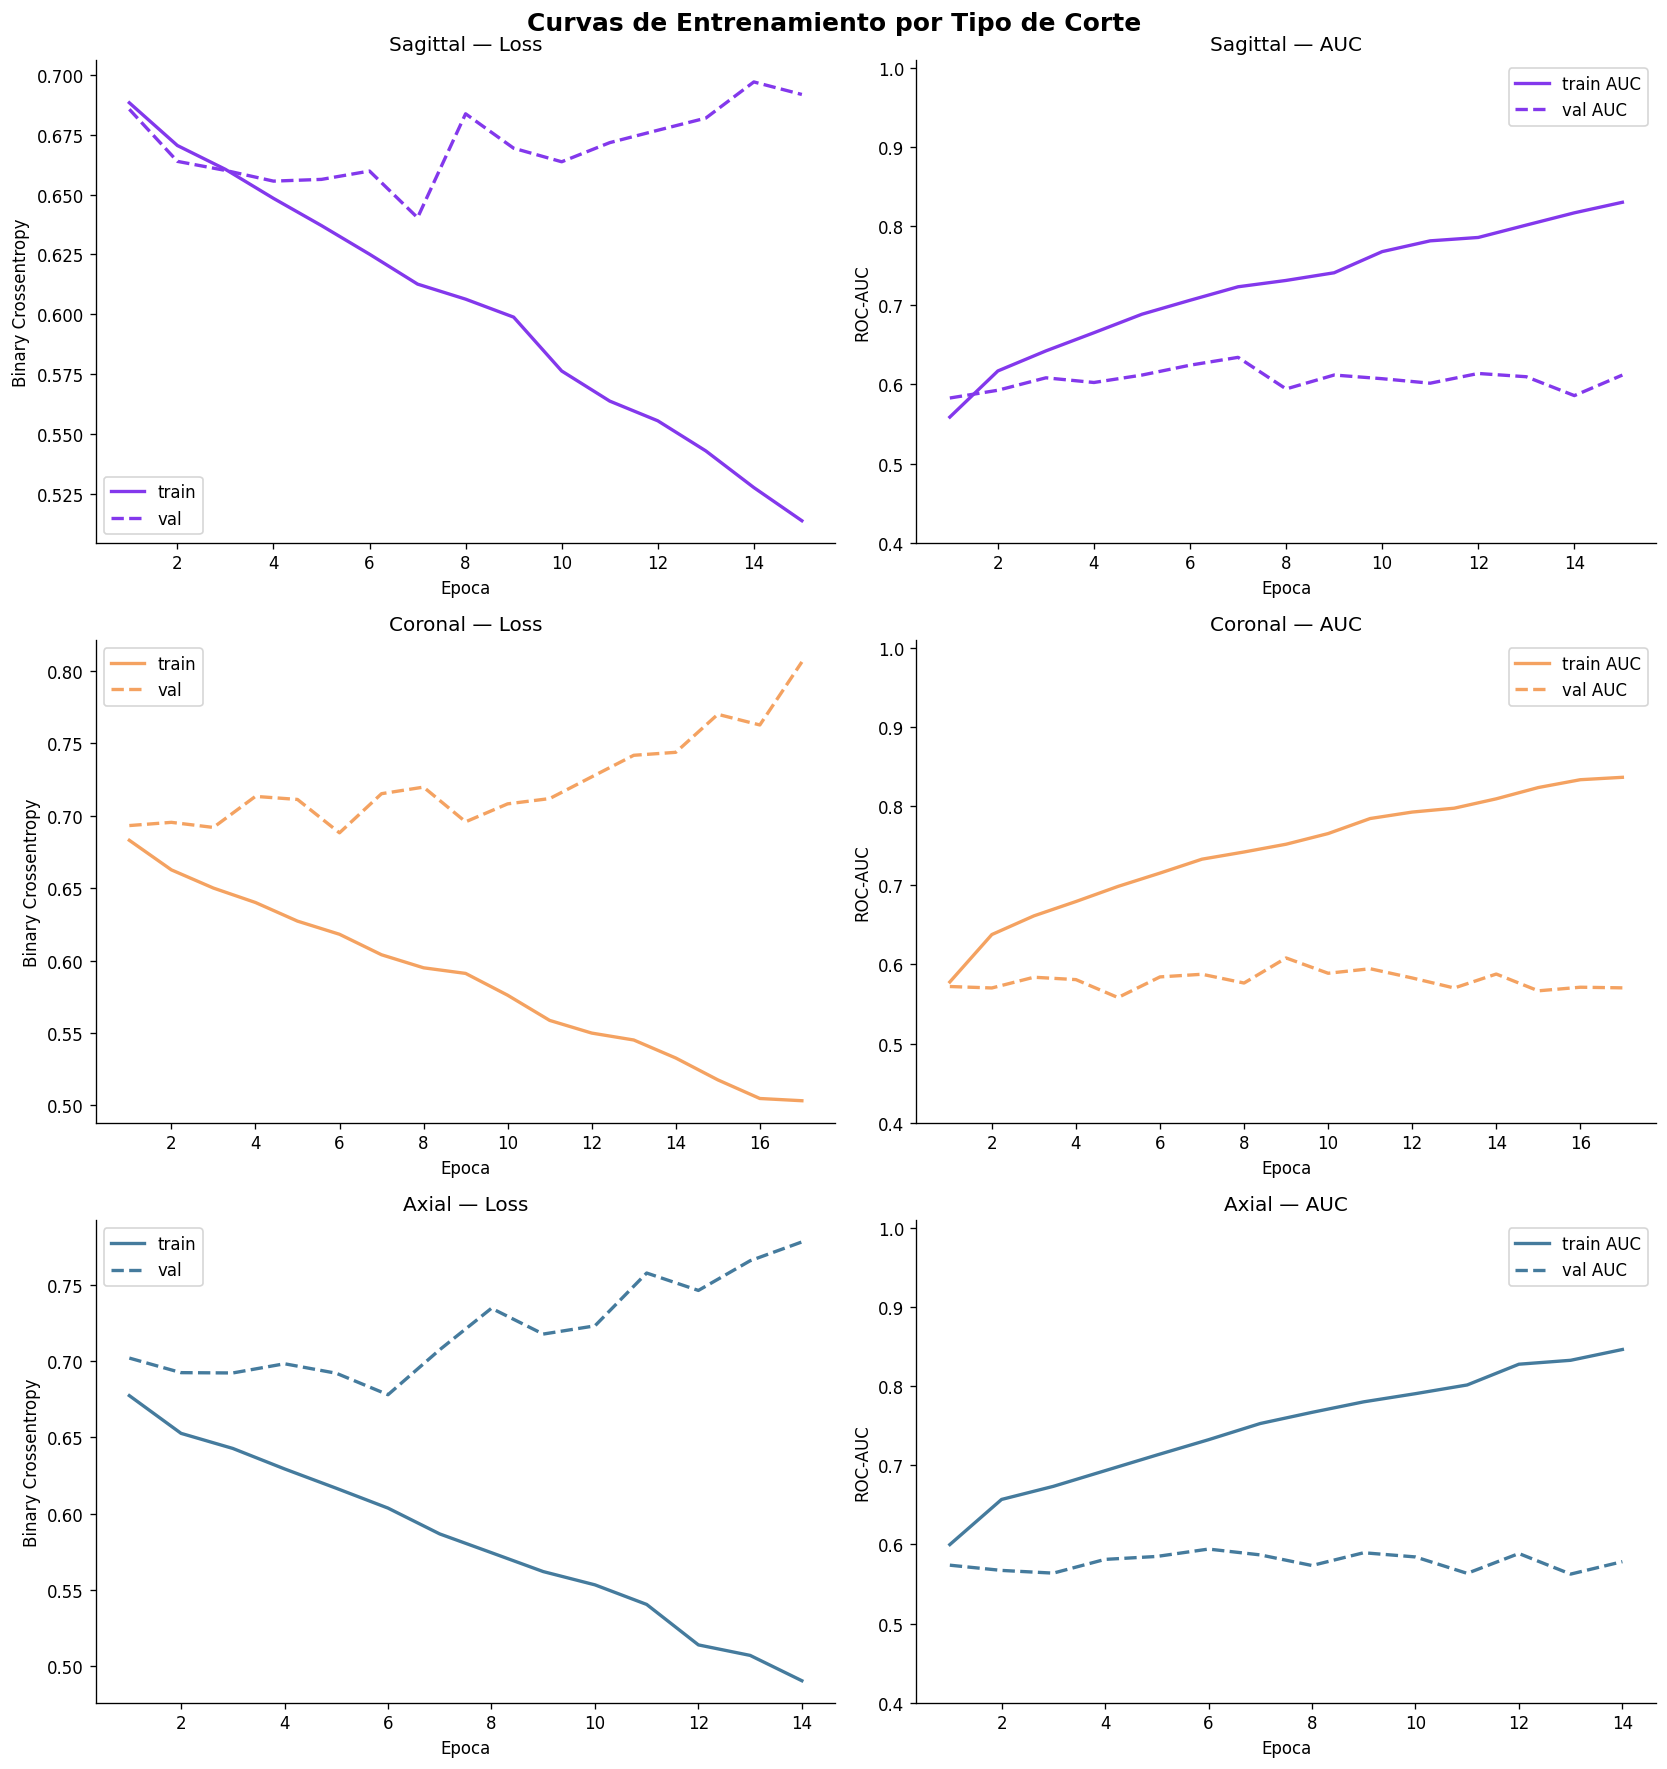

Grafico guardado en results/curvas_entrenamiento.png


In [8]:
fig, axes = plt.subplots(len(SLICE_TYPES), 2, figsize=(14, 5 * len(SLICE_TYPES)))
fig.suptitle('Curvas de Entrenamiento por Tipo de Corte', fontsize=15, fontweight='bold')

for row_i, slice_type in enumerate(SLICE_TYPES):
    hist       = training_histories[slice_type]
    color      = SLICE_COLORS[slice_type]
    epochs_ran = range(1, len(hist['loss']) + 1)

    ax_loss = axes[row_i, 0]
    ax_loss.plot(epochs_ran, hist['loss'],     color=color, label='train', linewidth=2)
    ax_loss.plot(epochs_ran, hist['val_loss'], color=color, label='val',   linewidth=2, linestyle='--')
    ax_loss.set_title(f'{slice_type.capitalize()} — Loss')
    ax_loss.set_xlabel('Epoca')
    ax_loss.set_ylabel('Binary Crossentropy')
    ax_loss.legend()

    ax_auc = axes[row_i, 1]
    ax_auc.plot(epochs_ran, hist['auc'],     color=color, label='train AUC', linewidth=2)
    ax_auc.plot(epochs_ran, hist['val_auc'], color=color, label='val AUC',   linewidth=2, linestyle='--')
    ax_auc.set_title(f'{slice_type.capitalize()} — AUC')
    ax_auc.set_xlabel('Epoca')
    ax_auc.set_ylabel('ROC-AUC')
    ax_auc.set_ylim(0.4, 1.01)
    ax_auc.legend()

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en results/curvas_entrenamiento.png')

---
## 7. Evaluacion en Test Set

In [10]:
def evaluate_model(model, df_files, slice_type, threshold=0.5):
    """
    Evalua el modelo sobre el test set del slice_type dado.
    y_proba -> P(Autism), y_true: NonAutism=0, Autism=1.
    """
    df_test = df_files[
        (df_files['split'] == 'test') & (df_files['slice_type'] == slice_type)
    ].reset_index(drop=True)

    ds_test = MRISliceDataset(df_test, transform=TRANSFORM_EVAL)
    dl_test = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=0)

    model.eval()
    all_proba, all_true = [], []

    with torch.no_grad():
        for xb, yb in dl_test:
            xb   = xb.to(DEVICE)
            pred = model(xb).squeeze(1)
            all_proba.extend(pred.cpu().numpy().tolist())
            all_true.extend(yb.numpy().tolist())

    y_proba = np.array(all_proba)
    y_true  = np.array(all_true, dtype=int)
    y_pred  = (y_proba >= threshold).astype(int)

    metrics = {
        'slice_type' : slice_type,
        'AUC'        : round(roc_auc_score(y_true, y_proba), 4),
        'Accuracy'   : round(accuracy_score(y_true, y_pred), 4),
        'F1'         : round(f1_score(y_true, y_pred, average='macro'), 4),
        'Precision'  : round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall'     : round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
    }
    return metrics, y_true, y_pred, y_proba


all_metrics = []
all_y_true  = {}
all_y_pred  = {}
all_y_proba = {}

for slice_type in SLICE_TYPES:
    m, yt, yp, ypr = evaluate_model(trained_models[slice_type], df_files, slice_type)
    all_metrics.append(m)
    all_y_true[slice_type]  = yt
    all_y_pred[slice_type]  = yp
    all_y_proba[slice_type] = ypr
    print(f'[{slice_type:>8}]  AUC={m["AUC"]:.4f}  Acc={m["Accuracy"]:.4f}  '
          f'F1={m["F1"]:.4f}  P={m["Precision"]:.4f}  R={m["Recall"]:.4f}')

df_metrics = pd.DataFrame(all_metrics).set_index('slice_type')
print(f'\nTabla completa — TEST SET:')
print(df_metrics.to_string())

df_metrics.to_csv(RESULTS_DIR / 'metricas_baseline.csv')
print(f'\nMetricas guardadas en results/metricas_baseline.csv')

[sagittal]  AUC=0.6606  Acc=0.6096  F1=0.6093  P=0.6095  R=0.6093
[ coronal]  AUC=0.6061  Acc=0.5651  F1=0.5628  P=0.5653  R=0.5642
[   axial]  AUC=0.6405  Acc=0.6062  F1=0.6048  P=0.6089  R=0.6071

Tabla completa — TEST SET:
               AUC  Accuracy      F1  Precision  Recall
slice_type                                             
sagittal    0.6606    0.6096  0.6093     0.6095  0.6093
coronal     0.6061    0.5651  0.5628     0.5653  0.5642
axial       0.6405    0.6062  0.6048     0.6089  0.6071

Metricas guardadas en results/metricas_baseline.csv


---
## 8. Matrices de Confusion

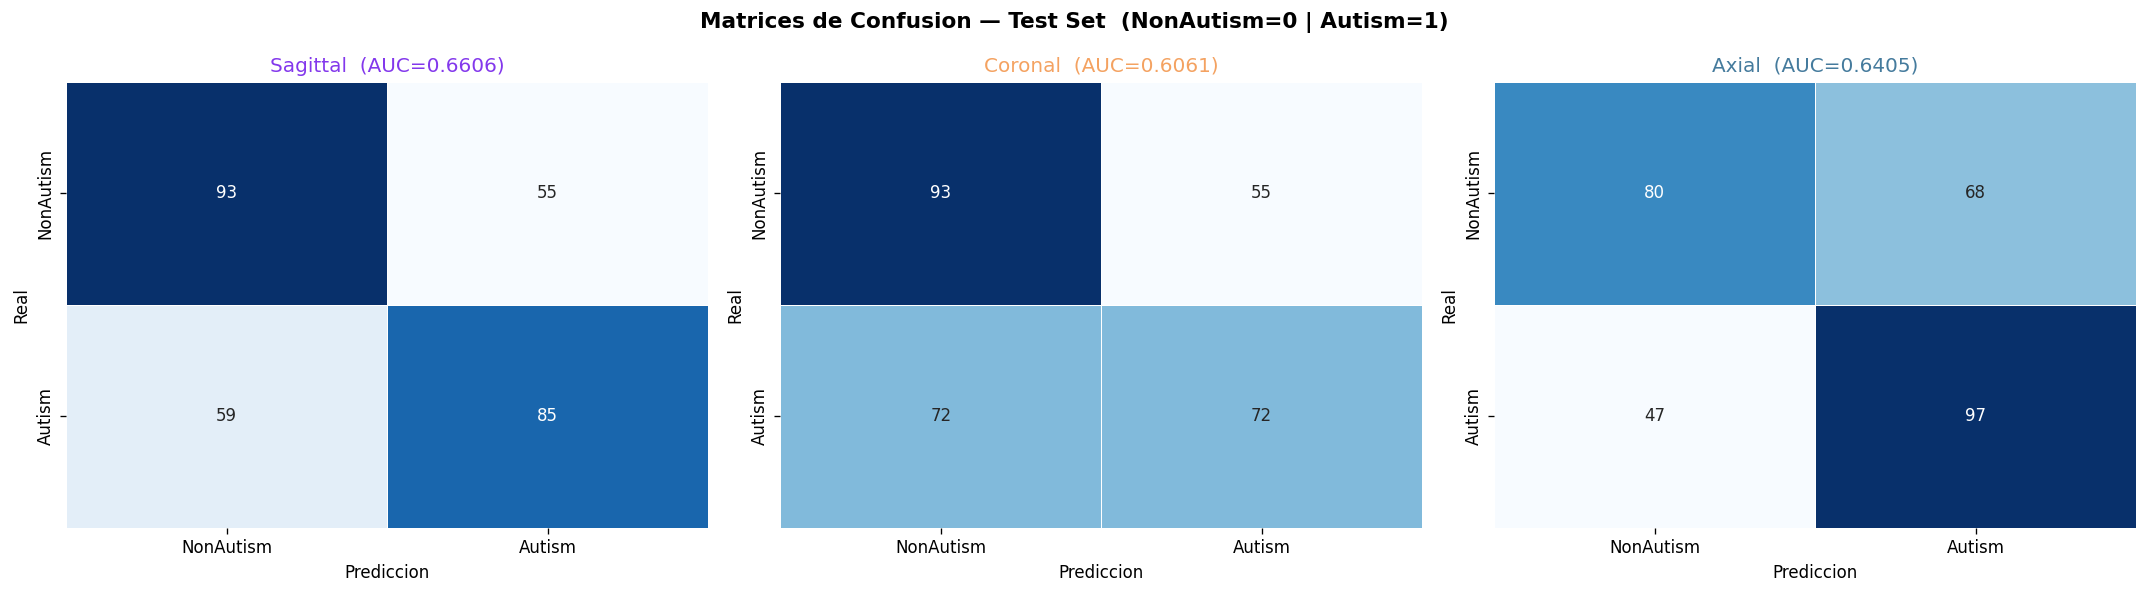

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusion — Test Set  (NonAutism=0 | Autism=1)',
             fontsize=13, fontweight='bold')

for ax, slice_type in zip(axes, SLICE_TYPES):
    cm = confusion_matrix(all_y_true[slice_type], all_y_pred[slice_type])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap='Blues', linewidths=0.5,
        xticklabels=['NonAutism', 'Autism'],
        yticklabels=['NonAutism', 'Autism'],
        cbar=False
    )
    auc_val = df_metrics.loc[slice_type, 'AUC']
    ax.set_title(f'{slice_type.capitalize()}  (AUC={auc_val:.4f})',
                 color=SLICE_COLORS[slice_type])
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Real')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'matrices_confusion_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Comparacion de Modelos — Barras por Metrica

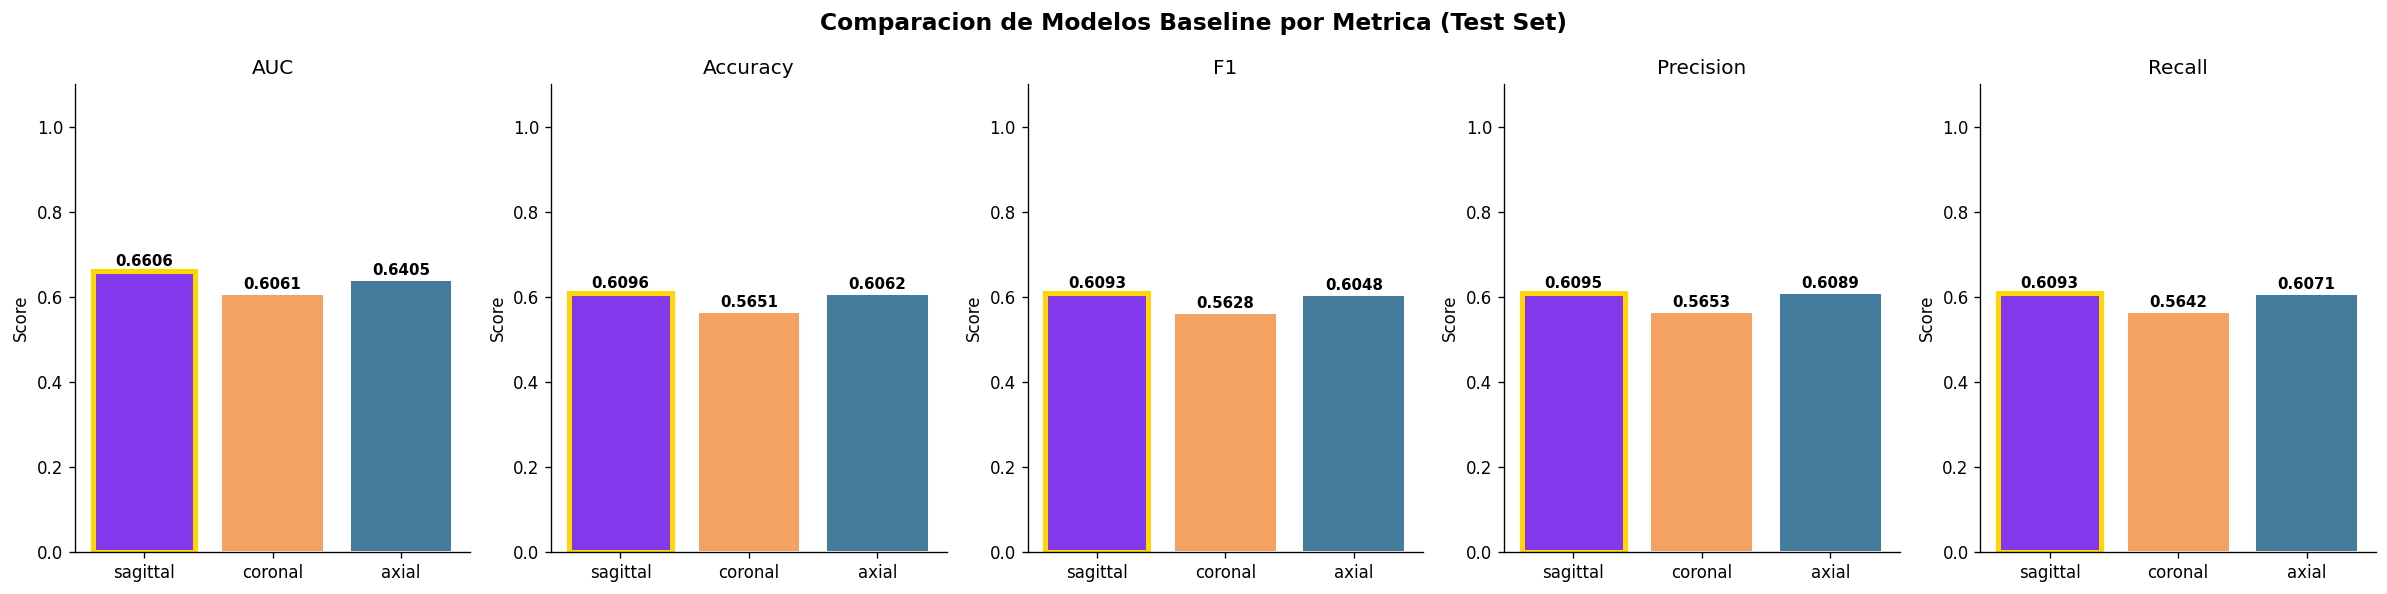

In [12]:
metrics_to_plot = ['AUC', 'Accuracy', 'F1', 'Precision', 'Recall']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 5))
fig.suptitle('Comparacion de Modelos Baseline por Metrica (Test Set)',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_to_plot):
    vals   = [df_metrics.loc[st, metric] for st in SLICE_TYPES]
    colors = [SLICE_COLORS[st] for st in SLICE_TYPES]
    bars   = ax.bar(SLICE_TYPES, vals, color=colors, edgecolor='white', linewidth=1.2)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')

    # Destacar el mejor con borde dorado
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'comparacion_modelos_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Curvas ROC Superpuestas

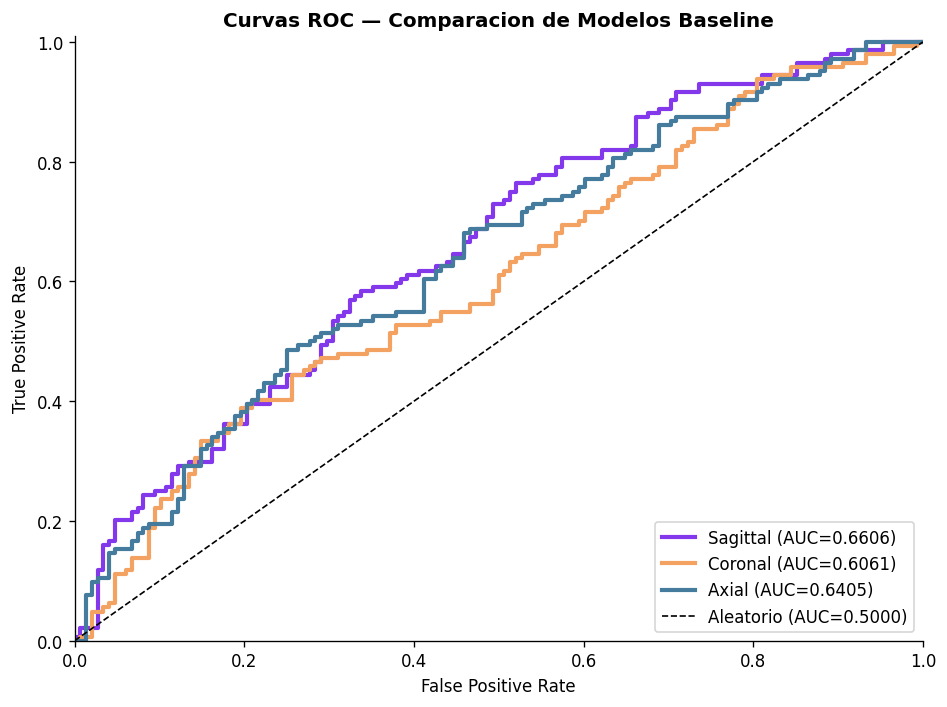

Grafico guardado en results/curvas_roc_baseline.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for slice_type in SLICE_TYPES:
    fpr, tpr, _ = roc_curve(all_y_true[slice_type], all_y_proba[slice_type])
    auc_val     = df_metrics.loc[slice_type, 'AUC']
    ax.plot(fpr, tpr, color=SLICE_COLORS[slice_type], linewidth=2.5,
            label=f'{slice_type.capitalize()} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC=0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — Comparacion de Modelos Baseline', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'curvas_roc_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en results/curvas_roc_baseline.png')

---
## 11. Extraccion de Embeddings

Extrae el vector de 256 dimensiones de la capa `embedding_layer` para los 3 splits.

In [15]:
def extract_embeddings(model, df_files, slice_type, split, batch_size=64):
    """
    Extrae embeddings (256-d) del modelo para un split dado.
    Usa model.encode(x) — capa anterior a dropout y clasificacion.
    Retorna (embeddings, labels, patient_ids).
    Labels: NonAutism=0, Autism=1.
    """
    df_split = df_files[
        (df_files['split'] == split) &
        (df_files['slice_type'] == slice_type)
    ].reset_index(drop=True)

    ds = MRISliceDataset(df_split, transform=TRANSFORM_EVAL)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    model.eval()
    all_embs, all_labels = [], []

    with torch.no_grad():
        for xb, yb in dl:
            xb   = xb.to(DEVICE)
            embs = model.encode(xb)   # vector embedding 256-d
            all_embs.extend(embs.cpu().numpy())
            all_labels.extend(yb.numpy().tolist())

    embeddings  = np.array(all_embs)
    labels      = np.array(all_labels, dtype=int)

    def extract_pid(fpath, st):
        stem = Path(fpath).stem
        idx  = stem.find(f'_{st}_')
        return stem[:idx] if idx >= 0 else stem

    patient_ids = [extract_pid(fp, slice_type) for fp in df_split['filepath'].tolist()]
    return embeddings, labels, patient_ids


print('Extrayendo embeddings...')
for slice_type in SLICE_TYPES:
    for split in ['train', 'val', 'test']:
        embs, labs, pids = extract_embeddings(
            trained_models[slice_type], df_files, slice_type, split
        )
        out_path = EMBEDDINGS_DIR / f'{slice_type}_{split}.npz'
        np.savez_compressed(
            str(out_path),
            embeddings  = embs,
            labels      = labs,
            patient_ids = np.array(pids, dtype=str)
        )
        print(f'   [{slice_type:>8} | {split:>5}]  shape={embs.shape}  -> {out_path.name}')

print(f'\nEmbeddings guardados en: {EMBEDDINGS_DIR.resolve()}')

Extrayendo embeddings...
   [sagittal | train]  shape=(8166, 256)  -> sagittal_train.npz
   [sagittal |   val]  shape=(292, 256)  -> sagittal_val.npz
   [sagittal |  test]  shape=(292, 256)  -> sagittal_test.npz
   [ coronal | train]  shape=(8166, 256)  -> coronal_train.npz
   [ coronal |   val]  shape=(292, 256)  -> coronal_val.npz
   [ coronal |  test]  shape=(292, 256)  -> coronal_test.npz
   [   axial | train]  shape=(8166, 256)  -> axial_train.npz
   [   axial |   val]  shape=(292, 256)  -> axial_val.npz
   [   axial |  test]  shape=(292, 256)  -> axial_test.npz

Embeddings guardados en: D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\data\embeddings


---
## 12. Resumen Final

In [17]:
print('='*70)
print('     RESUMEN FINAL — MODELOS BASELINE POR CORTE')
print('='*70)
print(f'  Framework       : PyTorch {torch.__version__}')
print(f'  Dispositivo     : {DEVICE}')
print(f'  Arquitectura    : CNN desde cero (4 bloques Conv + GAP + Dense)')
print(f'  Parametros      : ~{count_params(model_preview):,}')
print(f'  Imagen entrada  : {IMG_SIZE[0]}x{IMG_SIZE[1]}x3')
print(f'  Embedding dim   : 256')
print(f'  Clases          : NonAutism=0 | Autism=1')
print()
print(f'  Resultados en TEST SET:')
print(df_metrics[['AUC', 'Accuracy', 'F1']].to_string())
print()

best_auc_type = df_metrics['AUC'].idxmax()
best_f1_type  = df_metrics['F1'].idxmax()
print(f'  Mejor corte por AUC : {best_auc_type.upper()} ({df_metrics["AUC"].max():.4f})')
print(f'  Mejor corte por F1  : {best_f1_type.upper()} ({df_metrics["F1"].max():.4f})')
print()
print(f'  Modelos    -> {MODELS_DIR.resolve()}')
print(f'  Embeddings -> {EMBEDDINGS_DIR.resolve()}')
print(f'  Resultados -> {RESULTS_DIR.resolve()}')
print('='*70)


     RESUMEN FINAL — MODELOS BASELINE POR CORTE
  Framework       : PyTorch 2.11.0+cu128
  Dispositivo     : cuda
  Arquitectura    : CNN desde cero (4 bloques Conv + GAP + Dense)
  Parametros      : ~4,335,741
  Imagen entrada  : 224x224x3
  Embedding dim   : 256
  Clases          : NonAutism=0 | Autism=1

  Resultados en TEST SET:
               AUC  Accuracy      F1
slice_type                          
sagittal    0.6606    0.6096  0.6093
coronal     0.6061    0.5651  0.5628
axial       0.6405    0.6062  0.6048

  Mejor corte por AUC : SAGITTAL (0.6606)
  Mejor corte por F1  : SAGITTAL (0.6093)

  Modelos    -> D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\models\baseline
  Embeddings -> D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\data\embeddings
  Resultados -> D:\ANTIGRAVITY\proyectos\app_prediccion_autismo_multimodal\results
